In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
cardio_data = pd.read_csv('Cardiotocographic.csv')

In [4]:
cardio_data.tail()

,BPM,APC,FMPS,UCPS,DLPS,SDPS,PDPS,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,NSP
2121,140,0.000000,0.000000,0.007426,0.0,0.0,0.0,79,0.2,25,7.2,40,137,177,2
2122,140,0.000775,0.000000,0.006971,0.0,0.0,0.0,78,0.4,22,7.1,66,103,169,2
2123,140,0.000980,0.000000,0.006863,0.0,0.0,0.0,79,0.4,20,6.1,67,103,170,2
2124,140,0.000679,0.000000,0.006110,0.0,0.0,0.0,78,0.4,27,7.0,66,103,169,2
2125,142,0.001616,0.001616,0.008078,0.0,0.0,0.0,74,0.4,36,5.0,42,117,159,1


In [5]:
cardio_data.describe()

,BPM,APC,FMPS,UCPS,DLPS,SDPS,PDPS,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003170,0.009474,0.004357,0.001885,0.000004,0.000157,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,1.304327
std,9.840844,0.003860,0.046670,0.002940,0.002962,0.000063,0.000580,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,1.000000
25%,126.000000,0.000000,0.000000,0.001876,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,1.000000
50%,133.000000,0.001630,0.000000,0.004482,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,1.000000
75%,140.000000,0.005631,0.002512,0.006525,0.003264,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,1.000000
max,160.000000,0.019284,0.480634,0.014925,0.015385,0.001353,0.005348,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,3.000000


In [6]:
cardio_data['NSP'].value_counts()

,count
NSP,
1,1655
2,295
3,176


<Axes: xlabel='NSP', ylabel='count'>

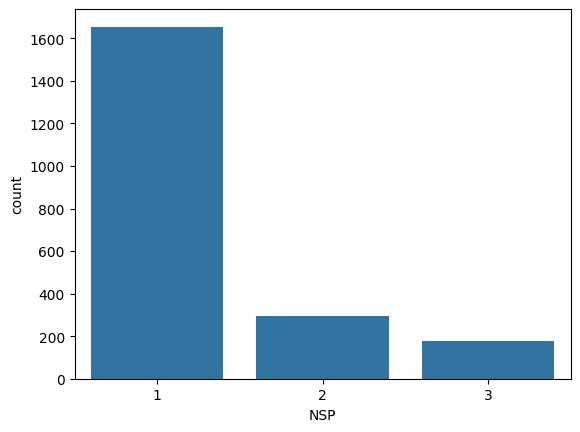

In [7]:
sns.countplot(cardio_data, x="NSP")

In [8]:
X = cardio_data.drop('NSP',axis=1)
y = cardio_data['NSP'] -1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = tf.keras.models.Sequential()

In [10]:
model.add(tf.keras.layers.Dense(9,activation='relu',input_shape=(14,)))
model.add(tf.keras.layers.Dense(3,activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 9)                   │             135 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              30 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 497 (1.95 KB)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 332 (1.30 KB)

In [103]:
class_weights = { 0:1, 1:5.6, 2:9.4}

history = model.fit(X_train, np.asarray(y_train), \
                    batch_size = 32, epochs= 200, \
                    verbose=2, class_weight=class_weights, \
                    validation_split=0.2)



Epoch 1/200
43/43 - 1s - 14ms/step - accuracy: 0.9279 - loss: 0.3327 - val_accuracy: 0.8735 - val_loss: 0.6687
Epoch 2/200
43/43 - 0s - 7ms/step - accuracy: 0.9287 - loss: 0.3311 - val_accuracy: 0.8735 - val_loss: 0.6710
Epoch 3/200
43/43 - 0s - 7ms/step - accuracy: 0.9294 - loss: 0.3308 - val_accuracy: 0.8735 - val_loss: 0.6677
Epoch 4/200
43/43 - 0s - 7ms/step - accuracy: 0.9287 - loss: 0.3314 - val_accuracy: 0.8735 - val_loss: 0.6686
Epoch 5/200
43/43 - 0s - 6ms/step - accuracy: 0.9265 - loss: 0.3331 - val_accuracy: 0.8765 - val_loss: 0.6741
Epoch 6/200
43/43 - 0s - 7ms/step - accuracy: 0.9257 - loss: 0.3375 - val_accuracy: 0.8735 - val_loss: 0.6712
Epoch 7/200
43/43 - 0s - 7ms/step - accuracy: 0.9287 - loss: 0.3292 - val_accuracy: 0.8735 - val_loss: 0.6713
Epoch 8/200
43/43 - 0s - 4ms/step - accuracy: 0.9294 - loss: 0.3340 - val_accuracy: 0.8735 - val_loss: 0.6739
Epoch 9/200
43/43 - 0s - 9ms/step - accuracy: 0.9294 - loss: 0.3313 - val_accuracy: 0.8735 - val_loss: 0.6671
Epoch 10/

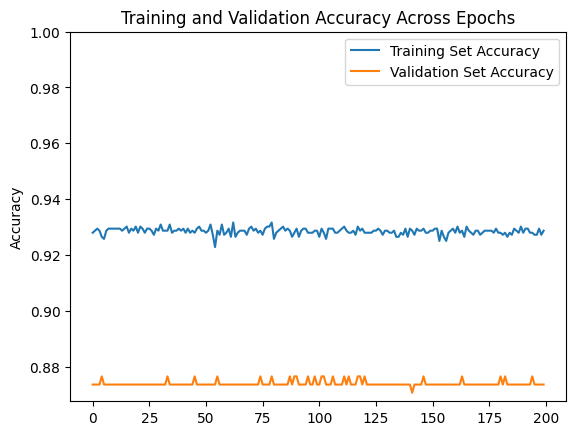

In [104]:
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

plt.plot(accuracy, label='Training Set Accuracy')
plt.plot(validation_accuracy, label='Validation Set Accuracy')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy Across Epochs')
plt.legend()


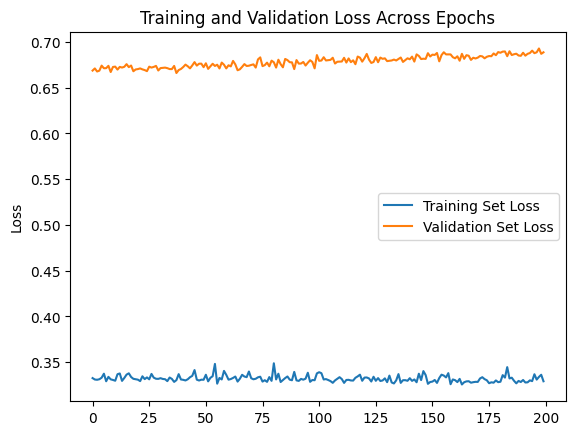

In [105]:
loss = history.history['loss']
validation_loss = history.history['val_loss']

plt.plot(loss, label='Training Set Loss')
plt.plot(validation_loss, label='Validation Set Loss')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend()


In [106]:
from sklearn.metrics import confusion_matrix, classification_report

In [107]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


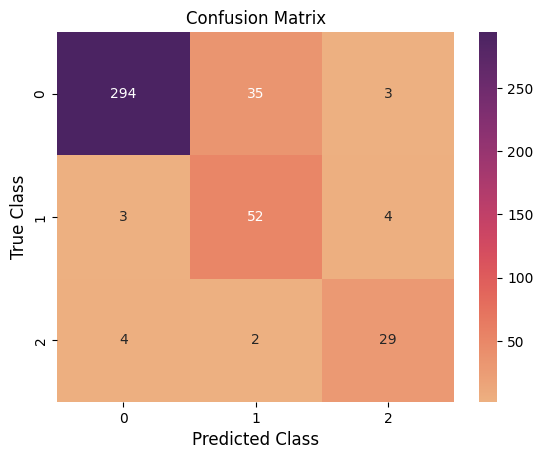

In [108]:
confusion_matrix = confusion_matrix(y_test,y_pred)


ax = sns.heatmap(confusion_matrix, cmap='flare',annot=True, fmt='d')


plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("True Class",fontsize=12)
plt.title("Confusion Matrix",fontsize=12)

plt.show()


In [109]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93       332
           1       0.58      0.88      0.70        59
           2       0.81      0.83      0.82        35

    accuracy                           0.88       426
   macro avg       0.79      0.87      0.82       426
weighted avg       0.91      0.88      0.89       426

